In [17]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

breaking the lme:

- high sc (e.g. 830)
- low number of patients (e.g. N_p = 10)

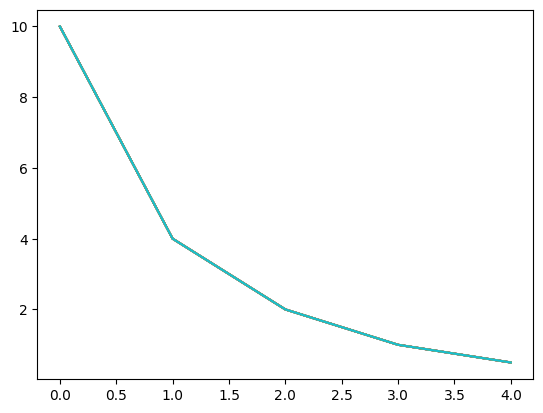

In [18]:
N_p = 10 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

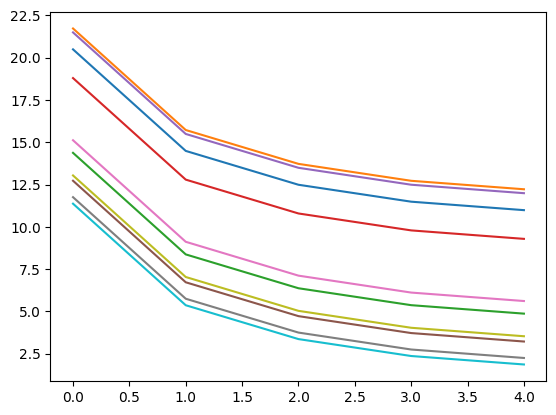

In [19]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

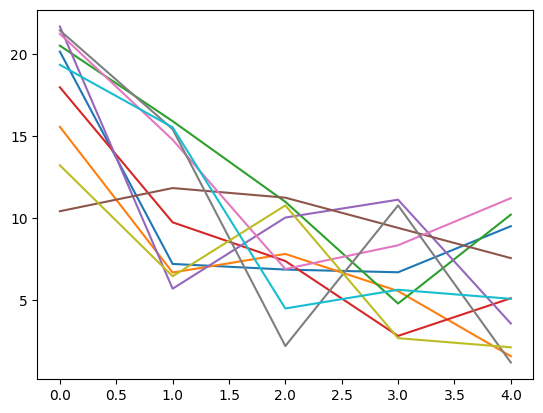

In [20]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [21]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   50        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    5         Log-Likelihood:       298.9970
Max. group size:    5         Converged:            Yes     
Mean group size:    5.0                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   16.086     0.583      27.575 0.000 14.943 17.229
Week[T.T1]  -6.000     0.000 -534872.859 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -713163.812 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -802309.288 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -846882.027 0.000 -9.500 -9.500
Patient Var  3.403 31976.607                                
============================================================

"""

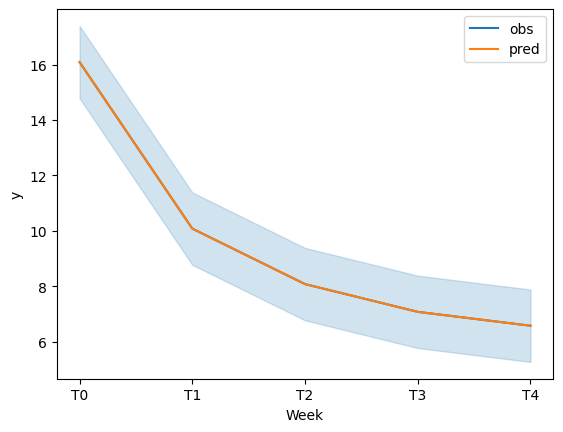

In [22]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [23]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   34        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    2         Log-Likelihood:       146.7922
Max. group size:    5         Converged:            Yes     
Mean group size:    3.4                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   16.086     0.727      22.137 0.000 14.662 17.510
Week[T.T1]  -6.000     0.000 -257471.882 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -334352.340 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -422983.917 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -460227.967 0.000 -9.500 -9.500
Patient Var  5.280 47888.488                                
============================================================

"""

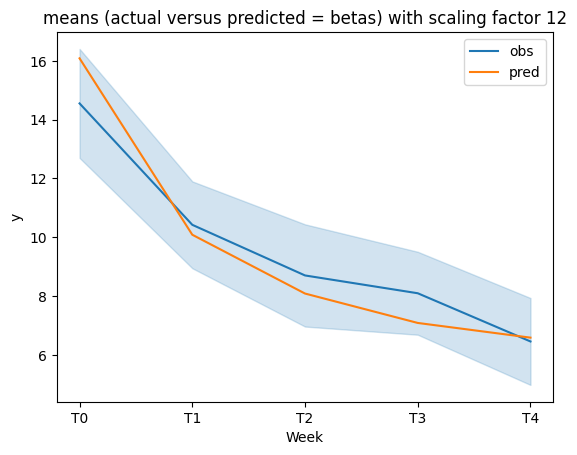

In [24]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

Additive differences between subjs: should make sense to use the intercept (fitted lines will be additively different by subj_intercept (re) value).

Multiplicative:

In [25]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

# log transform it
df_mult['y'] = np.log(df_mult['y'])

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/UWO/mporwal2/Docume

<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
======================================================
Model:            MixedLM Dependent Variable: y       
No. Observations: 50      Method:             REML    
No. Groups:       10      Scale:              0.2716  
Min. group size:  5       Log-Likelihood:     -40.9195
Max. group size:  5       Converged:          No      
Mean group size:  5.0                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    2.875    0.167 17.183 0.000  2.547  3.202
Week[T.T1]  -0.559    0.233 -2.397 0.017 -1.015 -0.102
Week[T.T2]  -0.906    0.233 -3.886 0.000 -1.363 -0.449
Week[T.T3]  -1.068    0.233 -4.583 0.000 -1.525 -0.611
Week[T.T4]  -1.385    0.233 -5.941 0.000 -1.841 -0.928
Patient Var  0.008    0.057                           
======================================================

"""

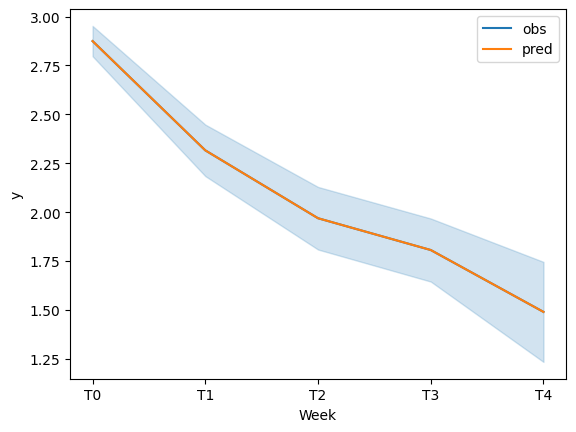

In [26]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [27]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
======================================================
Model:            MixedLM Dependent Variable: y       
No. Observations: 34      Method:             REML    
No. Groups:       10      Scale:              0.2603  
Min. group size:  2       Log-Likelihood:     -27.6724
Max. group size:  5       Converged:          Yes     
Mean group size:  3.4                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    2.944    0.239 12.342 0.000  2.476  3.411
Week[T.T1]  -0.555    0.308 -1.804 0.071 -1.158  0.048
Week[T.T2]  -0.972    0.317 -3.065 0.002 -1.593 -0.350
Week[T.T3]  -1.178    0.296 -3.985 0.000 -1.757 -0.598
Week[T.T4]  -1.613    0.294 -5.494 0.000 -2.188 -1.038
Patient Var  0.027    0.110                           
======================================================

"""

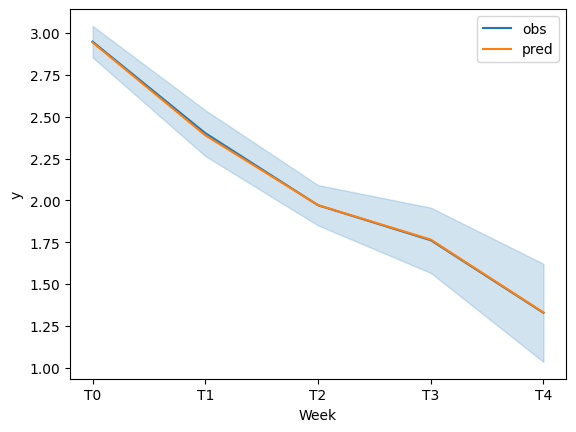

In [28]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)